## Setup and Data Validation

In this stage we load the processed data set, produced during task 3, for exploratory data analysis (EDA). Basic validation checks are repeated to confirm that the data is consistent with the earlier stages. 

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/diabetes_cleaned.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-null  int64


In [58]:
validation_summary = pd.Series({
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing values": df.isna().sum().sum(),
    "Duplicate rows retained": df.duplicated().sum(),
    "Minimum BMI": df["BMI"].min(),
    "Maximum BMI": df["BMI"].max()})

validation_summary

Rows                       253680
Columns                        22
Missing values                  0
Duplicate rows retained     24206
Minimum BMI                    12
Maximum BMI                    98
dtype: int64

In [59]:
ordinal_categories = {
    "Age": list(range(1, 14)),
    "Education": list(range(1, 7)),
    "Income": list(range(1, 9)),
    "GenHlth": list(range(1, 6))}

for column, categories in ordinal_categories.items():
    df[column] = pd.Categorical(df[column], categories=categories, ordered=True)

df[list(ordinal_categories)].dtypes

Age          category
Education    category
Income       category
GenHlth      category
dtype: object

The processed dataset contains 253,680 observations and 22 variables. No missing values are present. The duplicate records and extreme BMI observations remain because in stage 3 it was determined that they were plausible survey responses rather than confirmed data errors. Age, Education, Income, and GenHlth are restored as ordered categorical variables because CSV files do not preserve pandas categorical data types.


## Target Distribution and Class Imbalance

The distribution of `Diabetes_binary` is examined in order to determine if the target classes are balanced or not. Class 0 represents respondents without diabetes, where as class 1 represents respondents with prediabetes or diabetes.


In [60]:
target_summary = pd.DataFrame({
    "Count": df["Diabetes_binary"].value_counts().sort_index(),
    "Percentage": (
        df["Diabetes_binary"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2))})

target_summary.index = ["No diabetes", "Prediabetes/Diabetes"]
target_summary

,Count,Percentage
No diabetes,218334,86.07
Prediabetes/Diabetes,35346,13.93


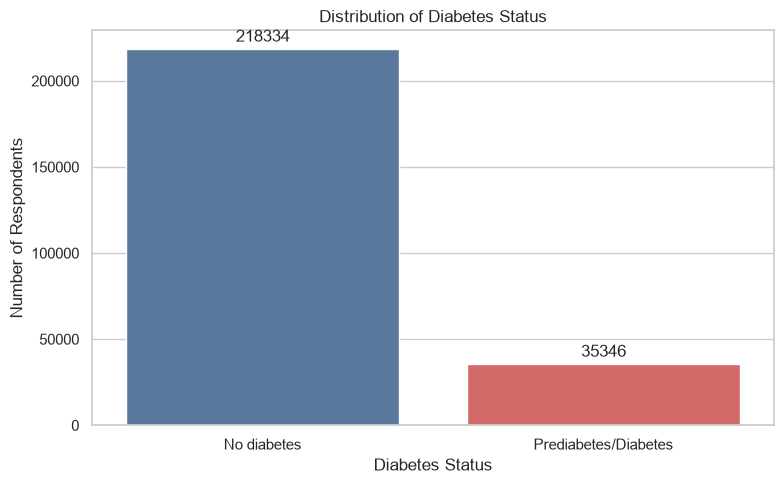

In [61]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Diabetes_binary",
    hue="Diabetes_binary",
    palette=["#4C78A8", "#E45756"],
    legend=False)

ax.set_title("Distribution of Diabetes Status")
ax.set_xlabel("Diabetes Status")
ax.set_ylabel("Number of Respondents")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No diabetes", "Prediabetes/Diabetes"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

It is clear from the graph that the target variable is very imbalanced. Almost 86.1% of respondents are in the no diabetes class, while only about 13.9% are classified as having prediabetes or diabetes. Consequently, raw counts must be interpreted carefully when comparing subgroups. Percentage based diabetes rates will be used in later analyses to account for differences in group size.

## BMI Distribution and Outliers


In [62]:
bmi_summary = df["BMI"].describe().round(2)
bmi_summary

count    253680.00
mean         28.38
std           6.61
min          12.00
25%          24.00
50%          27.00
75%          31.00
max          98.00
Name: BMI, dtype: float64

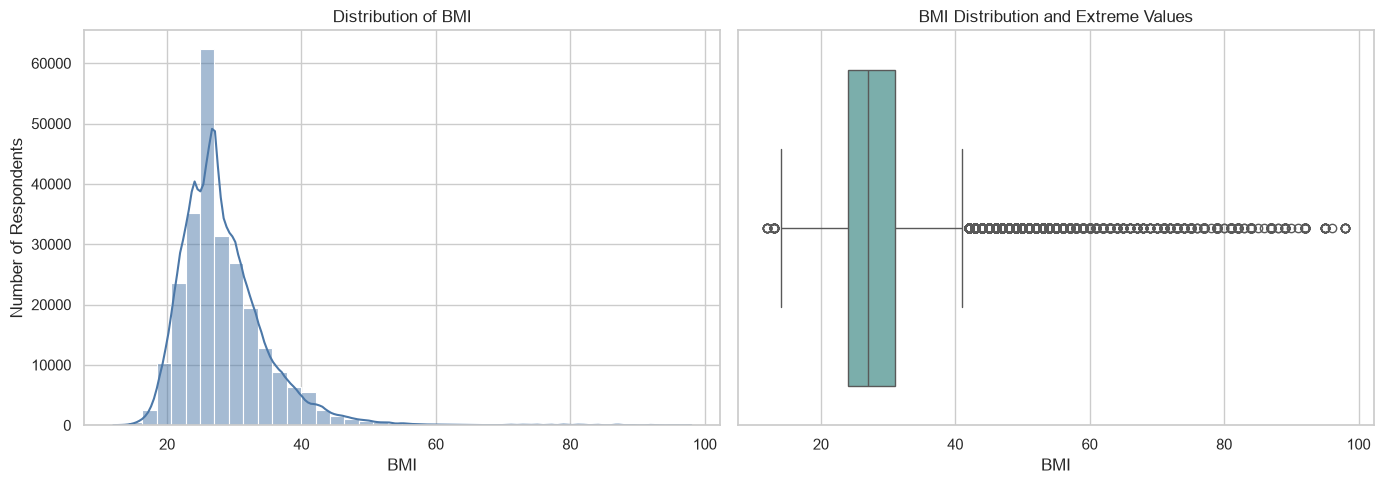

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="BMI",
    bins=40,
    kde=True,
    color="#4C78A8",
    ax=axes[0])

axes[0].set_title("Distribution of BMI")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Number of Respondents")

sns.boxplot(
    data=df,
    x="BMI",
    color="#72B7B2",
    ax=axes[1])

axes[1].set_title("BMI Distribution and Extreme Values")
axes[1].set_xlabel("BMI")

plt.tight_layout()
plt.show()

Through this we understand that the BMI has a median of 27 and a mean of approximately 28.38. This means that the distribution is positively skewed. Most observations are concentrated around the middle BMI values, while the upper tail extends to 98. The boxplot identifies numerous high BMI observations as statistical outliers. However, these values were retained during data cleaning because they remain physiologically possible and there was no clear evidence that they resulted from data entry errors.

## BMI by Diabetes Status

BMI distributions are compared between respondents without diabetes and respondents classified as having prediabetes or diabetes. This helps identify whether BMI is associated with the target variable.

In [64]:
bmi_by_status = (
    df.groupby("Diabetes_binary")["BMI"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2))

bmi_by_status.index = ["No diabetes", "Prediabetes/Diabetes"]
bmi_by_status

,count,mean,median,std,min,max
No diabetes,218334,27.81,27.0,6.29,12,98
Prediabetes/Diabetes,35346,31.94,31.0,7.36,13,98


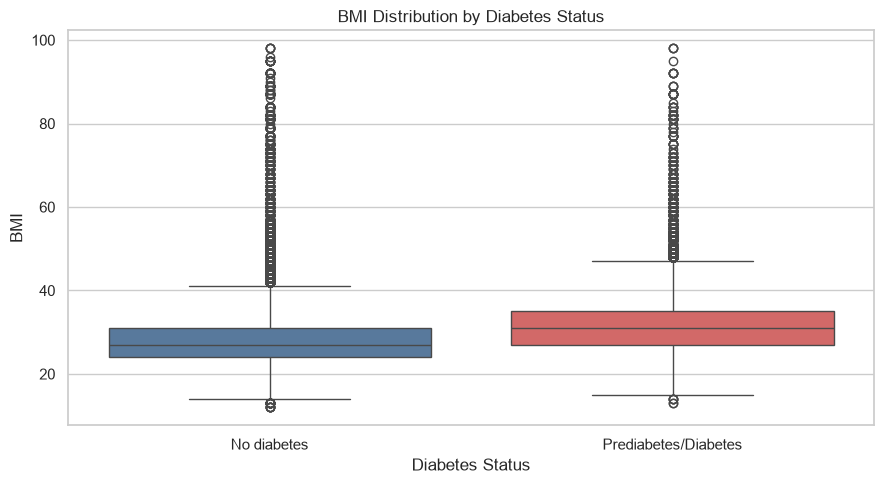

In [65]:
plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="BMI",
    hue="Diabetes_binary",
    palette=["#4C78A8", "#E45756"],
    legend=False)

ax.set_title("BMI Distribution by Diabetes Status")
ax.set_xlabel("Diabetes Status")
ax.set_ylabel("BMI")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No diabetes", "Prediabetes/Diabetes"])

plt.tight_layout()
plt.show()

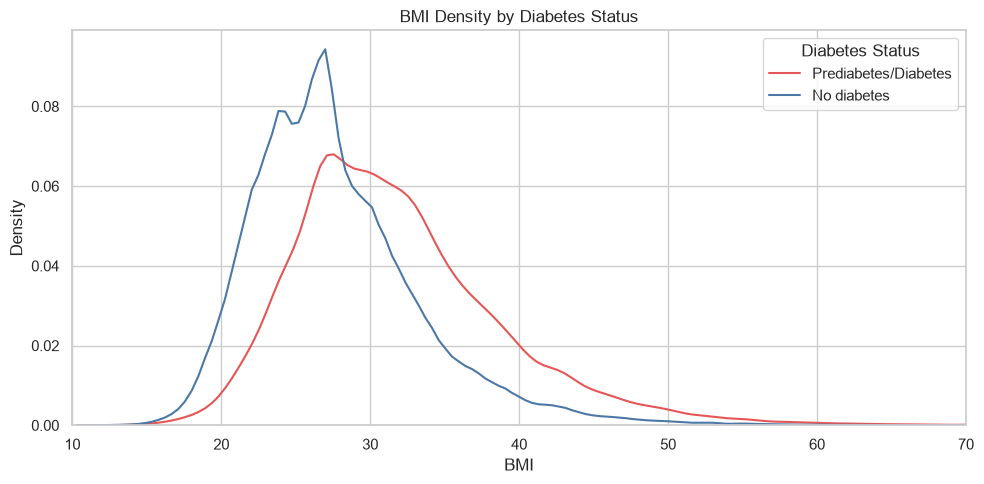

In [66]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    common_norm=False,
    fill=False,
    palette=["#4C78A8", "#E45756"])

plt.title("BMI Density by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.xlim(10, 70)
plt.legend(
    title="Diabetes Status",
    labels=["Prediabetes/Diabetes", "No diabetes"])

plt.tight_layout()
plt.show()

Respondants that are classified as having prediabetes or diabetes have higher mean and median BMI, 31.94 and 31 respectively, than those without diabetes whose mean and median are 27.81 and 27 respectively. This concludes that the BMI alone cannot distinguish the diabetes status. These results mearly indicate an association between higher BMI and diabetes status, but they do not sternly establish causation.



## Diabetes Prevalence by Age Bracket

Age is represented by 13 ordered bracket codes rather than respondents' literal ages. Diabetes prevalence is calculated within each bracket to account for differences in the sample size across the age groups.


In [67]:
age_summary = (
    df.groupby("Age", observed=False)["Diabetes_binary"]
    .agg(
        Respondents="count",
        Diabetes_Cases="sum",
        Diabetes_Rate="mean"))

age_summary["Diabetes_Rate"] = (
    age_summary["Diabetes_Rate"] * 100).round(2)

age_labels = {
    1: "18–24",
    2: "25–29",
    3: "30–34",
    4: "35–39",
    5: "40–44",
    6: "45–49",
    7: "50–54",
    8: "55–59",
    9: "60–64",
    10: "65–69",
    11: "70–74",
    12: "75–79",
    13: "80+"}

age_summary_display = age_summary.reset_index()

age_summary_display.insert(
    1,
    "Age_Group",
    age_summary_display["Age"].astype(int).map(age_labels))

age_summary_display.style.hide(axis="index")

Age,Age_Group,Respondents,Diabetes_Cases,Diabetes_Rate
1,18–24,5700,78,1.370000
2,25–29,7598,140,1.840000
3,30–34,11123,314,2.820000
4,35–39,13823,626,4.530000
5,40–44,16157,1051,6.500000
6,45–49,19819,1742,8.790000
7,50–54,26314,3088,11.740000
8,55–59,30832,4263,13.830000
9,60–64,33244,5733,17.250000
10,65–69,32194,6558,20.370000


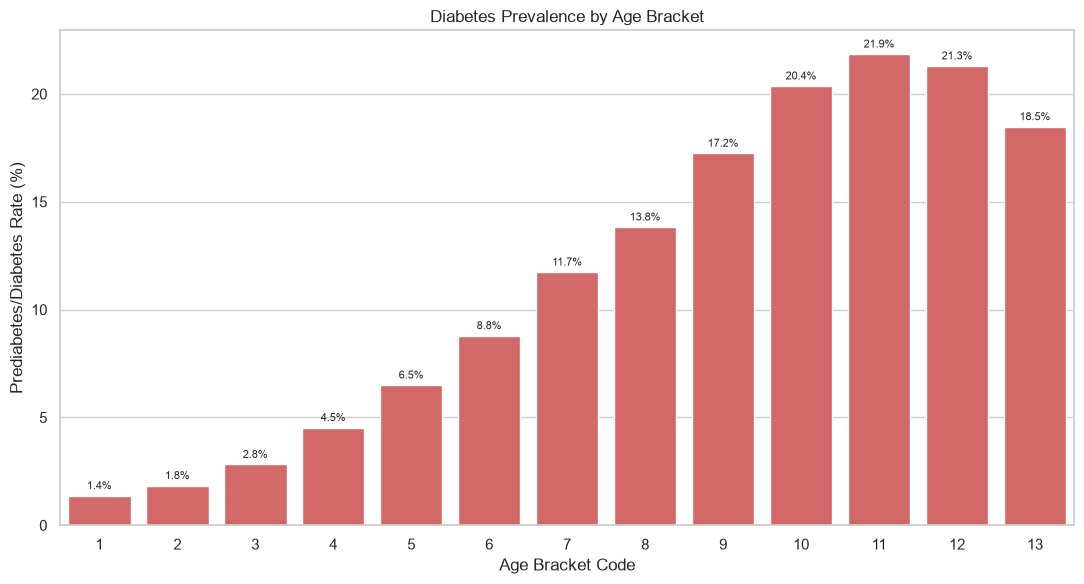

In [68]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=age_summary.reset_index(),
    x="Age",
    y="Diabetes_Rate",
    color="#E45756")

ax.set_title("Diabetes Prevalence by Age Bracket")
ax.set_xlabel("Age Bracket Code")
ax.set_ylabel("Prediabetes/Diabetes Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

Diabetes prevalence generally increases across the ordered age brackets. The younger groups have lower rates and old groups have substantially higher rates. This basically indicates that there is a strong association between age group and diabetes status in the dataset. The pattern however does not establish that age alone causes diabetes, as other health and lifestyle factors may also differ between the age groups. 


## Diabetes Prevalence by General Health

`GenHlth` is an ordered self reported health rating, where 1 represents excellent health and 5 represents poor health. Diabetes prevalence is calculated within each category to examine whether general health, that is regarded as substandard, is associated with diabetes status.


In [69]:
health_summary = (
    df.groupby("GenHlth", observed=False)["Diabetes_binary"]
    .agg(
        Respondents="count",
        Diabetes_Cases="sum",
        Diabetes_Rate="mean"))

health_summary["Diabetes_Rate"] = (
    health_summary["Diabetes_Rate"] * 100).round(2)

health_labels = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"}

health_summary_display = health_summary.reset_index()

health_summary_display.insert(
    1,
    "Health_Rating",
    health_summary_display["GenHlth"]
    .astype(int)
    .map(health_labels))

health_summary_display.style.hide(axis="index")

GenHlth,Health_Rating,Respondents,Diabetes_Cases,Diabetes_Rate
1,Excellent,45299,1140,2.520000
2,Very good,89084,6381,7.160000
3,Good,75646,13457,17.790000
4,Fair,31570,9790,31.010000
5,Poor,12081,4578,37.890000


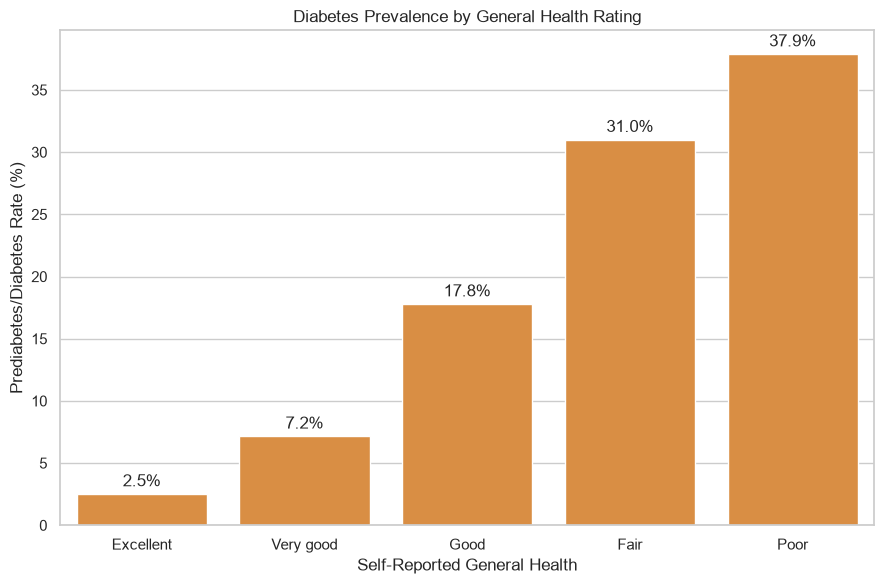

In [70]:
health_plot = health_summary_display.copy()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=health_plot,
    x="Health_Rating",
    y="Diabetes_Rate",
    color="#F28E2B")

ax.set_title("Diabetes Prevalence by General Health Rating")
ax.set_xlabel("Self-Reported General Health")
ax.set_ylabel("Prediabetes/Diabetes Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

The prevalence of diabetes increases as self reported general health worsens. Respondents who describe their health as fair or poor have a considerably higher diabetes rate than those reporting excellent or very good health. This is one of the clearest relationships observed in the dataset yet. However, self reported health and diabetes status could influence one another, therefore the analysis does not sternly establish causation. 


## High Blood Pressure, High Cholesterol, and Diabetes

High blood pressure and high cholesterol are examined because they are important health indicators that could be associated with diabetes. Diabetes prevalence is calculated separately for respondents with and without each condition.

In [71]:
indicator_rows = []

indicator_labels = {
    "HighBP": "High Blood Pressure",
    "HighChol": "High Cholesterol"}

for column, label in indicator_labels.items():
    summary = (
        df.groupby(column)["Diabetes_binary"]
        .agg(
            Respondents="count",
            Diabetes_Cases="sum",
            Diabetes_Rate="mean"
)
        .reset_index())

    summary["Indicator"] = label
    summary["Status"] = summary[column].map({
        0: "No",
        1: "Yes"})
    summary["Diabetes_Rate"] = (summary["Diabetes_Rate"] * 100).round(2)

    indicator_rows.append(
        summary[
            [
                "Indicator",
                "Status",
                "Respondents",
                "Diabetes_Cases",
                "Diabetes_Rate"
            ]
        ]
    )

indicator_summary = pd.concat(
    indicator_rows,
    ignore_index=True)

indicator_summary.style.hide(axis="index")

Indicator,Status,Respondents,Diabetes_Cases,Diabetes_Rate
High Blood Pressure,No,144851,8742,6.040000
High Blood Pressure,Yes,108829,26604,24.450000
High Cholesterol,No,146089,11660,7.980000
High Cholesterol,Yes,107591,23686,22.010000


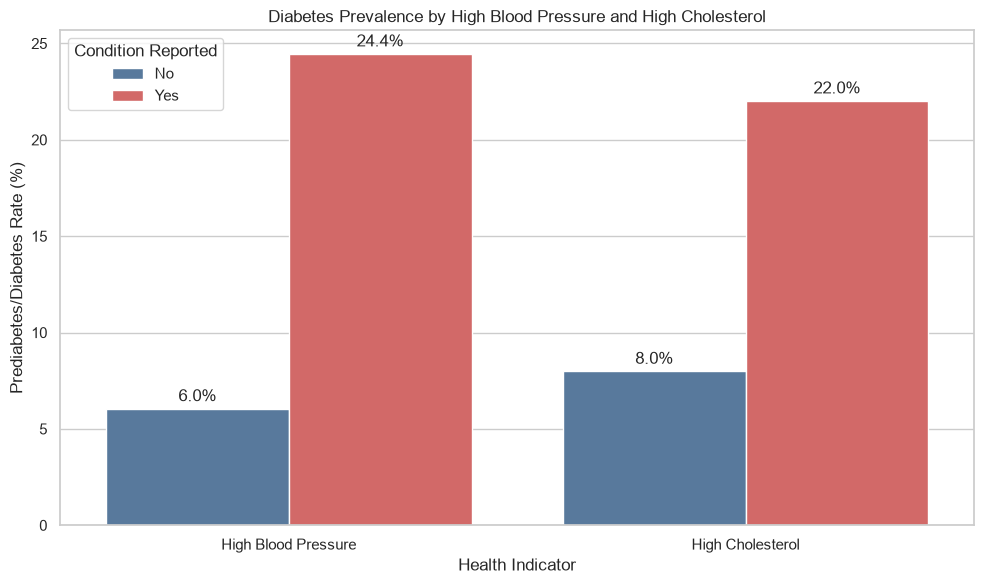

In [72]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=indicator_summary,
    x="Indicator",
    y="Diabetes_Rate",
    hue="Status",
    palette={
        "No": "#4C78A8",
        "Yes": "#E45756"})

ax.set_title(
    "Diabetes Prevalence by High Blood Pressure and High Cholesterol")
ax.set_xlabel("Health Indicator")
ax.set_ylabel("Prediabetes/Diabetes Rate (%)")
ax.legend(title="Condition Reported")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Prevalence of diabetes is considerably higher among respondents who report high blood pressure or high cholesterol. These findings show that there is a strong association between both conditions and diabetes status in this dataset. But this data cannot fully establish that either condition directly causes diabetes.


## Lifestyle Indicators and Diabetes Prevalence

Prevalence of diabetes is compared across selected lifestyle indicators such as smoking history, physical activity, daily fruit consumption, daily vegetable consumption, and heavy alcohol consumption. Rates are then calculated separately for respondents who answered yes and no to each indicator. 

In [73]:
lifestyle_labels = {
    "Smoker": "Smoking History",
    "PhysActivity": "Physical Activity",
    "Fruits": "Daily Fruit",
    "Veggies": "Daily Vegetables",
    "HvyAlcoholConsump": "Heavy Alcohol Consumption"}

lifestyle_rows = []

for column, label in lifestyle_labels.items():
    summary = (
        df.groupby(column)["Diabetes_binary"]
        .agg(
            Respondents="count",
            Diabetes_Cases="sum",
            Diabetes_Rate="mean").reset_index())

    summary["Lifestyle_Indicator"] = label
    summary["Status"] = summary[column].map({
        0: "No",
        1: "Yes"})

    summary["Diabetes_Rate"] = (
        summary["Diabetes_Rate"] * 100).round(2)

    lifestyle_rows.append(
        summary[
            [
                "Lifestyle_Indicator",
                "Status",
                "Respondents",
                "Diabetes_Cases",
                "Diabetes_Rate"]])

lifestyle_summary = pd.concat(
    lifestyle_rows,
    ignore_index=True)

lifestyle_summary.style.hide(axis="index")

Lifestyle_Indicator,Status,Respondents,Diabetes_Cases,Diabetes_Rate
Smoking History,No,141257,17029,12.060000
Smoking History,Yes,112423,18317,16.290000
Physical Activity,No,61760,13059,21.140000
Physical Activity,Yes,191920,22287,11.610000
Daily Fruit,No,92782,14653,15.790000
Daily Fruit,Yes,160898,20693,12.860000
Daily Vegetables,No,47839,8610,18.000000
Daily Vegetables,Yes,205841,26736,12.990000
Heavy Alcohol Consumption,No,239424,34514,14.420000
Heavy Alcohol Consumption,Yes,14256,832,5.840000


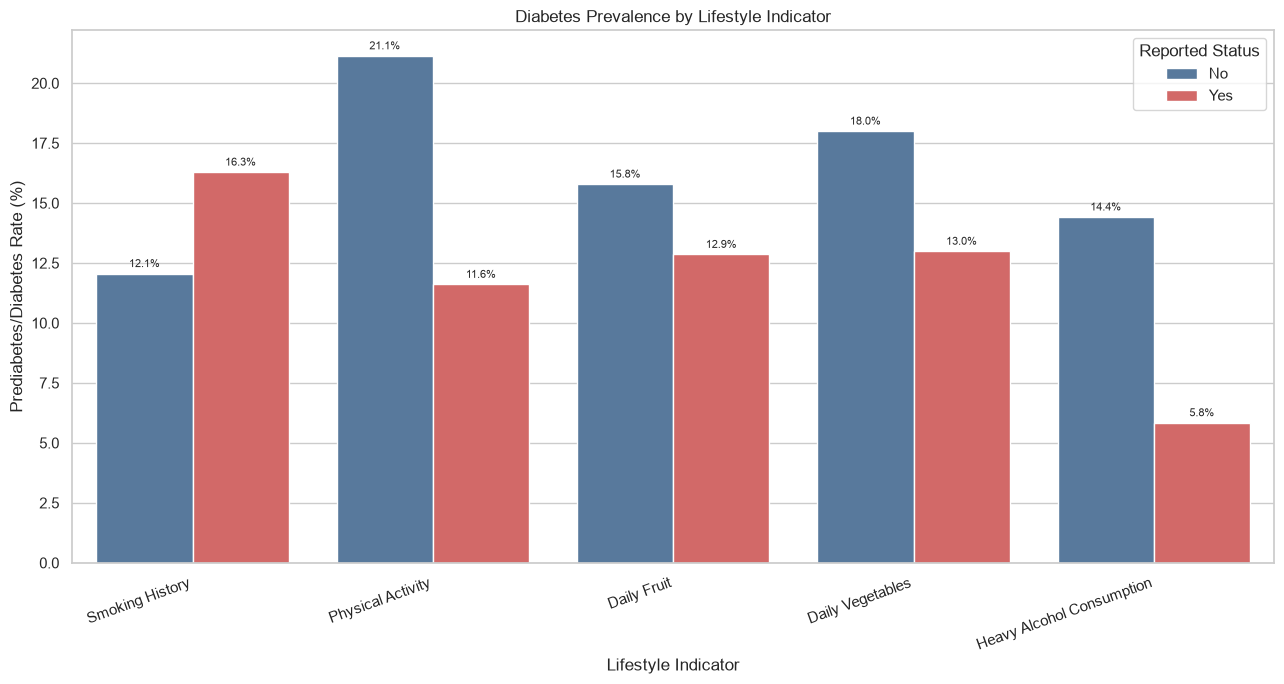

In [74]:
plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=lifestyle_summary,
    x="Lifestyle_Indicator",
    y="Diabetes_Rate",
    hue="Status",
    palette={
        "No": "#4C78A8",
        "Yes": "#E45756"})

ax.set_title("Diabetes Prevalence by Lifestyle Indicator")
ax.set_xlabel("Lifestyle Indicator")
ax.set_ylabel("Prediabetes/Diabetes Rate (%)")
ax.legend(title="Reported Status")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Prevalence of diabetes is different across the lifestyle groups: 

- Respondents with a smoking history have a higher diabetes rate (16.3%) than non-smokers (12.1%). 

- Respondents with high physical activity have a considerably lower rate (11.6%) than those reporting no physical activity (21.1%). This is the largest difference among the indicators examined. 

- Respondants who consume fruits and vegetables daily show lower diabetes prevalence, 12.9% and 13% respectively, compared to non daily consumers, 15.% and 18% respectively.

- Respondents classified as heavy alcohol consumers show a lower diabetes rate (5.8%) than those who are not (14.4%). This counterintuitive result should not be interpreted as evidence that heavy alcohol consumption is good for preventing diabetes. Different factors such as the respondants' age, health status or the size of the groups may contribute to this pattern.

Overall, these comparisons show associations between lifestyle indicators and diabetes status, but they do not demonstrate causaion.


## Correlation Analysis

Spearman correlation is used to examine the direction and strength of relationships among selected health, demographic, and lifestyle variables. It was selected because the analysis includes ordered category codes, such as age, income, education, and general health, alongside binary and numerical variables. The heatmap provides an overview of how these variables are associated with one another and with diabetes status. 


In [75]:
correlation_columns = [
    "Diabetes_binary",
    "BMI",
    "HighBP",
    "HighChol",
    "GenHlth",
    "Age",
    "Income",
    "Education",
    "PhysHlth",
    "MentHlth",
    "DiffWalk",
    "HeartDiseaseorAttack",
    "Stroke",
    "PhysActivity"]

correlation_df = df[correlation_columns].copy()

for column in ["GenHlth", "Age", "Income", "Education"]:
    correlation_df[column] = correlation_df[column].astype(int)

spearman_corr = correlation_df.corr(method="spearman")
spearman_corr.round(2)

,Diabetes_binary,BMI,HighBP,HighChol,GenHlth,Age,Income,Education,PhysHlth,MentHlth,DiffWalk,HeartDiseaseorAttack,Stroke,PhysActivity
Diabetes_binary,1.00,0.23,0.26,0.20,0.29,0.18,-0.16,-0.12,0.16,0.04,0.22,0.18,0.11,-0.12
BMI,0.23,1.00,0.24,0.14,0.26,-0.02,-0.09,-0.12,0.12,0.05,0.18,0.06,0.02,-0.14
HighBP,0.26,0.24,1.00,0.30,0.30,0.34,-0.18,-0.14,0.15,0.02,0.22,0.21,0.13,-0.13
HighChol,0.20,0.14,0.30,1.00,0.21,0.27,-0.09,-0.07,0.12,0.04,0.14,0.18,0.09,-0.08
GenHlth,0.29,0.26,0.30,0.21,1.00,0.15,-0.35,-0.28,0.45,0.24,0.42,0.24,0.16,-0.26
Age,0.18,-0.02,0.34,0.27,0.15,1.00,-0.18,-0.10,0.05,-0.16,0.20,0.23,0.13,-0.09
Income,-0.16,-0.09,-0.18,-0.09,-0.35,-0.18,1.00,0.45,-0.22,-0.15,-0.30,-0.14,-0.12,0.20
Education,-0.12,-0.12,-0.14,-0.07,-0.28,-0.10,0.45,1.00,-0.11,-0.05,-0.19,-0.10,-0.07,0.20
PhysHlth,0.16,0.12,0.15,0.12,0.45,0.05,-0.22,-0.11,1.00,0.31,0.42,0.16,0.13,-0.18
MentHlth,0.04,0.05,0.02,0.04,0.24,-0.16,-0.15,-0.05,0.31,1.00,0.19,0.03,0.05,-0.08


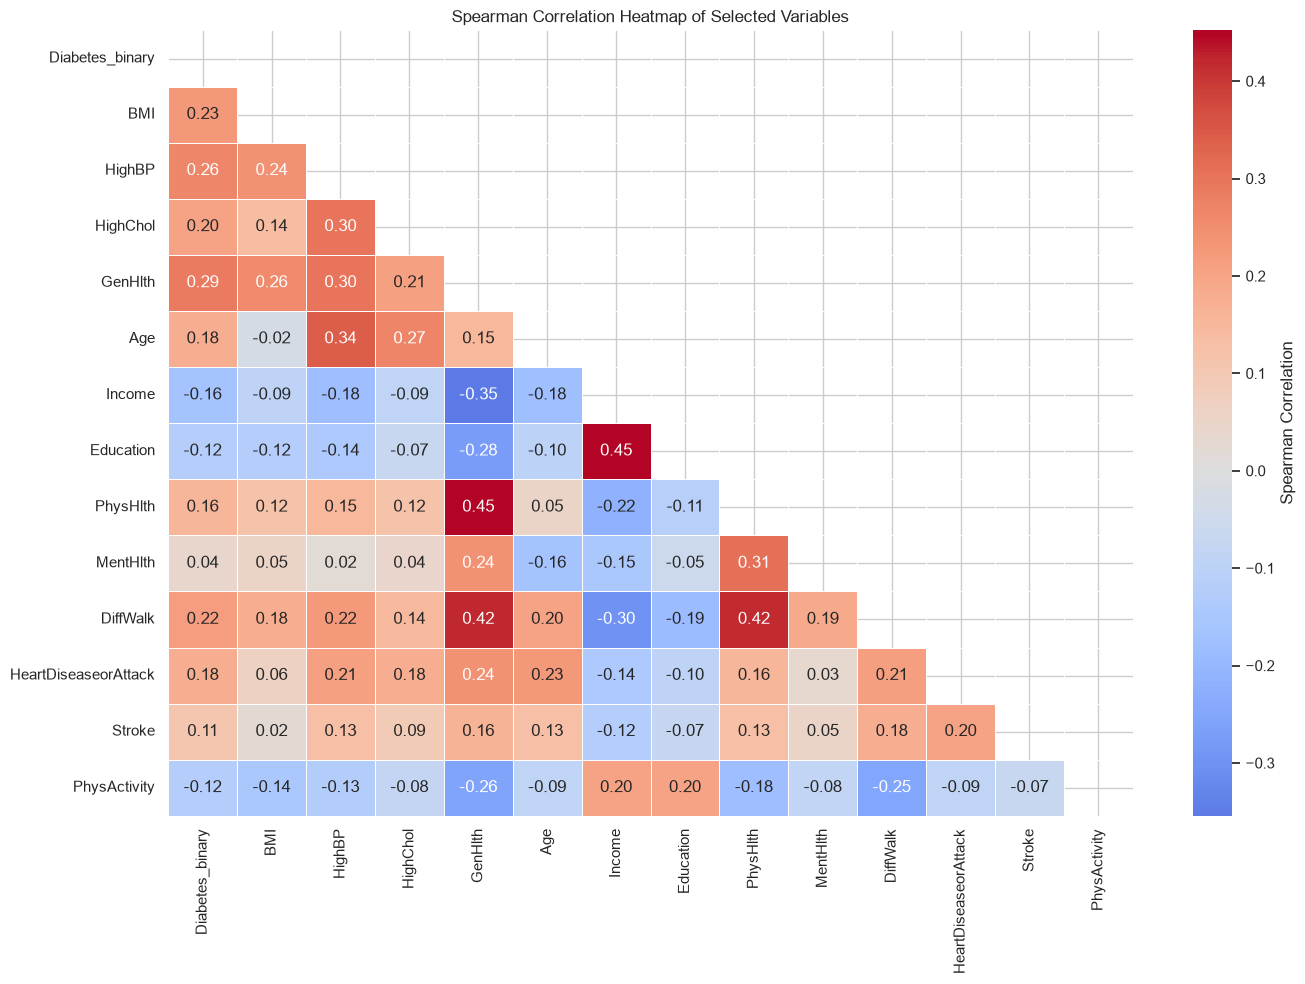

In [76]:
import numpy as np

mask = np.triu(
    np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation"})

plt.title("Spearman Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

## Interpretation

No single variable has a strong correlation with diabetes status, indicating that diabetes is associated with a combination of health, demographic, and lifestyle factors rather than one variable alone.

Among the selected variables, poorer general health has the strongest positive correlation with diabetes status (0.29), followed by high blood pressure (0.26), BMI (0.23), difficulty in walking (0.22), and high cholesterol (0.20). Age and a history of heart disease or heart attack each show a correlation of 0.18. These results are consistent with the earlier group comparisons, which found higher prevalence of diabetes among respondents with poorer health indicators and higher BMI.

Income (-0.16), education (-0.12), and physical activity (-0.12) have negative correlations with diabetes status. Becasue higher code represents higher income and education, these results indicate that diabetes is somewhat more common among respondents in lower income and education groups. The physical activity correlation indicates lower prevalence of diabetes among more active respondents.

The number of poor mental health days has almost no correlation with diabetes status (0.04), while stroke has a small positive correlation (0.11). Among the predictors, the strongest relationships involve education and income (0.45) and the connections between general health, poor physical health days, and difficulty in walking (0.42–0.45). These patterns suggest that some socioeconomic and physical health variables contain related or overlapping information.

These correlations describe the direction and strength of monotonic relationships but do not establish causation. The generally weak to moderate coefficients also suggest that no single feature completely explains diabetes status.

## Key Findings

- The processed dataset contains 253,680 observations and 22 variables, with no missing values.

- The target is substantially imbalanced, approximately 86.1% of respondents have no diabetes, while 13.9% are classified as having prediabetes or diabetes.

- BMI is positively skewed and contains medically extreme but plausible values. Respondents in the prediabetes/diabetes group have a higher mean BMI (31.94) than respondents without diabetes (27.81).

- Diabetes prevalence generally increases across the ordered age brackets, rising from 1.4% in the youngest bracket to a peak of 21.9% in bracket 11 before declining slightly in the final two brackets.

- Poorer self reported general health, high blood pressure, high cholesterol, and difficulty in walking are associated with higher diabetes prevalence.

- Respondents reporting physical activity, daily fruit consumption, or daily vegetable consumption generally have lower prevalence of diabetes than respondents who do not report these behaviours.

- The correlation analysis found no single strongly correlated predictor. General health, high blood pressure, BMI, difficulty in walking, and high cholesterol showed the largest positive correlations with diabetes status among the selected variables.

- The combination of health, demographic, and lifestyle relationships indicates that the dataset contains useful information for the later development of a diabetes classification model.

## Data Quality and Limitations

- Exact matching rows were kept because different survey participants may have provided the same answers, becuase the dataset is dominated by binary and low cardinality variables. Since the dataset has no unique participant identifier, these rows could not be confirmed as accidental duplicates.

- Extreme BMI observations were retained because they were considered physiologically possible and showed no clear evidence of data entry errors.

- The dataset is based largely on self reported survey responses and may therefore contain recall error, reporting bias, or inaccurate health information.

- Age, education, income, and general health are recorded as ordered groups, such as age or income brackets, rather than exact numerical measurements.

- The target classes are imbalanced, with substantially more respondents without diabetes than with prediabetes/diabetes. This imbalance will need to be considered when evaluating future classification models.

- The relationships identified through this EDA are observational associations and do not establish causal effects.